In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

os.environ["CUDA_VISIBLE_DEVICES"] = "1"

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report
)
from scipy.stats import mannwhitneyu

from accelerate import Accelerator

from models.main_architecture import MultiModalEncoder, MultiModalContrastiveModel
from training.data_processing import SCL_Multi_Dataset, get_dataloaders
from training.engine import prepare_multiview_inputs_v2
from training.calibration import (
    ExpectedCalibrationError,
    plot_calibration_curve,
    plot_reliability_diagram,
    analyze_calibration
)

from training.decision_curve_analysis import (
    compute_dca,
    compute_dca_with_cooldown,
    plot_dca_curve,
    analyze_optimal_threshold,
    apply_cooldown_alerts
)

from training.run import parse_arguments
from utils import set_seed

from IPython.display import Image, display

# Notebook settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

## Configuration

In [2]:
# Model & Experiment
EXPERIMENT_ID = "9"
MODEL_PATH = f"./output/checkpoints/experiment_{EXPERIMENT_ID}/single_stage_best_model.pth"
OUTPUT_DIR = f"./output/calibration_analysis/experiment_{EXPERIMENT_ID}"

ROOT_DIR = '/home/DAHS1/gangmin/my_research/'
TS_PATH = ROOT_DIR + 'src/test/final_ts_dataset_2026_0223.ftr'
IMG_PATH = ROOT_DIR + 'src/test/total_cxr_df_5days_20260128.ftr'
TEXT_PATH = ROOT_DIR + 'src/test/final_text_df_20260128.ftr'
DEMO_PATH = ROOT_DIR + 'processed/final_demo_df.ftr'

RANDOM_SEED = 42
set_seed(RANDOM_SEED)

# Initialize Accelerator with bf16 (consistent with training)
accelerator = Accelerator(
    mixed_precision="bf16",
    device_placement=True
)
device = accelerator.device
print(f"Device: {device}")
print(f"Mixed Precision: bf16")

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR}")

🎯 [SEED] All seeds set to 42 for reproducibility
Device: cuda
Mixed Precision: bf16
Output directory: ./output/calibration_analysis/experiment_9


In [3]:
ts_df = pd.read_feather(TS_PATH)
img_df = pd.read_feather(IMG_PATH)
text_df = pd.read_feather(TEXT_PATH)
demo_df = pd.read_feather(DEMO_PATH)

print(f"Time-series: {ts_df.shape}")
print(f"Images: {img_df.shape}")
print(f"Text: {text_df.shape}")
print(f"Demographics: {demo_df.shape}")

Time-series: (1039542, 34)
Images: (1039542, 4)
Text: (1039542, 4)
Demographics: (12985, 25)


In [4]:
args = parse_arguments()

train_loader, val_loader, test_loader, train_sampler = get_dataloaders(
        ts_df=ts_df,
        cxr_df=img_df,
        text_df=text_df,
        demo_df=demo_df,
        args=args,
        num_workers=0
    )

print(f"✅ Test dataset created: {len(test_loader.dataset)} samples")

[Dataset Split] Using Edema-based stratification for multi-task learning

[Dataset Split] Stratified patient-level distribution:
Train patients: 10609
Val patients:   2122
Test patients:  1415

Train Set:
  Edema Negative=330019, Edema Positive=113397, Unlabeled+Uncertain=42551
  Subtype (P(subtype|edema=1)): Non-cardio=40180, Cardio=26724

Val Set:
  Edema Negative=65888, Edema Positive=23008, Unlabeled+Uncertain=8834
  Subtype (P(subtype|edema=1)): Non-cardio=8973, Cardio=4971

Test Set:
  Edema Negative=43021, Edema Positive=15272, Unlabeled+Uncertain=5885
  Subtype (P(subtype|edema=1)): Non-cardio=5405, Cardio=3883
[Dataset] Total features (including observed_mask): 29
[Dataset] Image preprocessing config: to_3ch=False
[Dataset] Total features (including observed_mask): 29
[Dataset] Image preprocessing config: to_3ch=False
[Dataset] Total features (including observed_mask): 29
[Dataset] Image preprocessing config: to_3ch=False

[Train] Window-level Label Distribution (Multi-task)
E

In [5]:
encoder = MultiModalEncoder(args, disable_cxr=False, disable_txt=False).to(device)
model = MultiModalContrastiveModel(encoder).to(device)

# Load checkpoint
if os.path.exists(MODEL_PATH):
    checkpoint = torch.load(MODEL_PATH, map_location=device)
    model.load_state_dict(checkpoint)
    print(f"✅ Model loaded from: {MODEL_PATH}")
else:
    raise FileNotFoundError(f"Model not found: {MODEL_PATH}")

model = accelerator.prepare(model)
model.eval()
print("Model set to evaluation mode")

[MultiModalEncoder] DenseNet121: 2,160,128 / 6,966,034 params trainable


[MultiModalEncoder] BioClinicalBERT: 14,766,336 / 108,310,272 params trainable
[MultiModalEncoder] DemographicEncoder initialized with 24 input features
✅ Model loaded from: ./output/checkpoints/experiment_9/single_stage_best_model.pth
Model set to evaluation mode


## Get Predictions to DataFrame

In [6]:
def get_predictions_with_metadata(model, dataloader, device):
    model.eval()
    dataset = dataloader.dataset
    max_length = int(512)
    
    all_data = []
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Getting predictions"):
            for k in ['edema_labels', 'subtype_labels', 'window_mask', 'valid_seq_mask']:
                batch[k] = batch[k].to(device, non_blocking=True)
            edema_labels = batch['edema_labels']
            subtype_labels = batch['subtype_labels']

            demo_features = batch.get('demo_features')
            if demo_features is not None:
                demo_features = demo_features.to(device, non_blocking=True)

            img_index_tensor = batch['img_index_tensor']
            txt_index_tensor = batch['text_index_tensor']
            has_cxr = (img_index_tensor != -1).long().to(device, non_blocking=True)   # [B, W, T]
            has_text = (txt_index_tensor != -1).long().to(device, non_blocking=True)  # [B, W, T]
    
            ts_series, cxr_data, text_data, has_cxr, has_text = prepare_multiview_inputs_v2(
                batch=batch,
                device=device,
                has_cxr=has_cxr,
                has_text=has_text,
                dataset=dataset,
                disable_cxr=False,
                disable_txt=False,
                max_length=max_length
            )
            
            window_mask = batch['window_mask'].to(device)
            seq_valid_mask = batch['valid_seq_mask'].to(device)
            demo_features = batch['demo_features'].to(device) if batch['demo_features'] is not None else None
            
            model_outputs = model(
                args=args,
                ts_series=ts_series,
                cxr_data=cxr_data,
                text_data=text_data,
                has_cxr=has_cxr,
                has_text=has_text,
                window_mask=window_mask,
                seq_valid_mask=seq_valid_mask,
                demo_features=demo_features,
            )
            
            edema_logits = model_outputs['edema_logits'].squeeze(-1)  # [B, W]
            subtype_logits = model_outputs['subtype_logits']  # [B, W, 2]
            edema_probs = torch.sigmoid(edema_logits)  # [B, W]
            subtype_probs = torch.softmax(subtype_logits, dim=-1)  # [B, W, 2]
            
            valid_mask = window_mask.bool()
            
            B, W = edema_logits.shape
            
            for b in range(B):
                stay_id = batch['stay_ids'][b]
                
                for w in range(W):
                    if valid_mask[b, w]:
                        has_cxr_val = has_cxr[b, w, 0].item() if has_cxr.dim() == 3 and has_cxr.shape[2] > 0 else 0
                        has_text_val = has_text[b, w, 0].item() if has_text.dim() == 3 and has_text.shape[2] > 0 else 0
                        
                        all_data.append({
                            'stay_id': stay_id,
                            'window_idx': w,
                            'edema_true': edema_labels[b, w].item(),
                            'edema_logit': edema_logits[b, w].item(),
                            'edema_prob': edema_probs[b, w].item(),
                            'subtype_true': subtype_labels[b, w].item(),
                            'subtype_logit_ncpe': subtype_logits[b, w, 0].item(),
                            'subtype_logit_cpe': subtype_logits[b, w, 1].item(),
                            'subtype_prob_ncpe': subtype_probs[b, w, 0].item(),
                            'subtype_prob_cpe': subtype_probs[b, w, 1].item(),
                            'has_cxr': has_cxr_val,
                            'has_text': has_text_val,
                        })
    
    predictions_df = pd.DataFrame(all_data)
    print(f"\n✅ Collected {len(predictions_df)} predictions")
    
    return predictions_df

predictions_df = get_predictions_with_metadata(model, test_loader, device)

Getting predictions:   0%|          | 0/12 [00:00<?, ?it/s]

[StratifiedPatientSampler][Rank 0] Yielding 12 batches

✅ Collected 61159 predictions


In [7]:
predictions_df.head()

,stay_id,window_idx,edema_true,edema_logit,edema_prob,subtype_true,subtype_logit_ncpe,subtype_logit_cpe,subtype_prob_ncpe,subtype_prob_cpe,has_cxr,has_text
0,30009753,0,0,-3.109375,0.042722,-1,-0.750000,1.062500,0.140336,0.859664,0,1
1,30009753,1,0,-3.015625,0.046725,-1,-0.718750,1.039062,0.147065,0.852935,0,0
2,30009753,2,0,-2.968750,0.048858,-1,-0.742188,1.070312,0.140336,0.859664,0,0
3,30009753,3,0,-2.984375,0.048137,-1,-0.761719,1.093750,0.135232,0.864768,0,1
4,30009753,4,0,-2.859375,0.054199,-1,-0.773438,1.156250,0.126785,0.873215,0,0


In [8]:
predictions_df['edema_true'].value_counts()

edema_true
-1    27451
 0    24545
 1     9163
Name: count, dtype: int64

In [9]:
predictions_df['subtype_true'].value_counts()

subtype_true
-1    29655
 0    20361
 1    11143
Name: count, dtype: int64

---

# 1. Calibration Analysis

### 1.1 Edema Detection Calibration

Edema Detection:
  ECE: 0.0305
  AUROC: 0.9105
  AUPRC: 0.8137
📊 Calibration plot saved: ./output/calibration_analysis/experiment_9/edema_detection_calibration.png


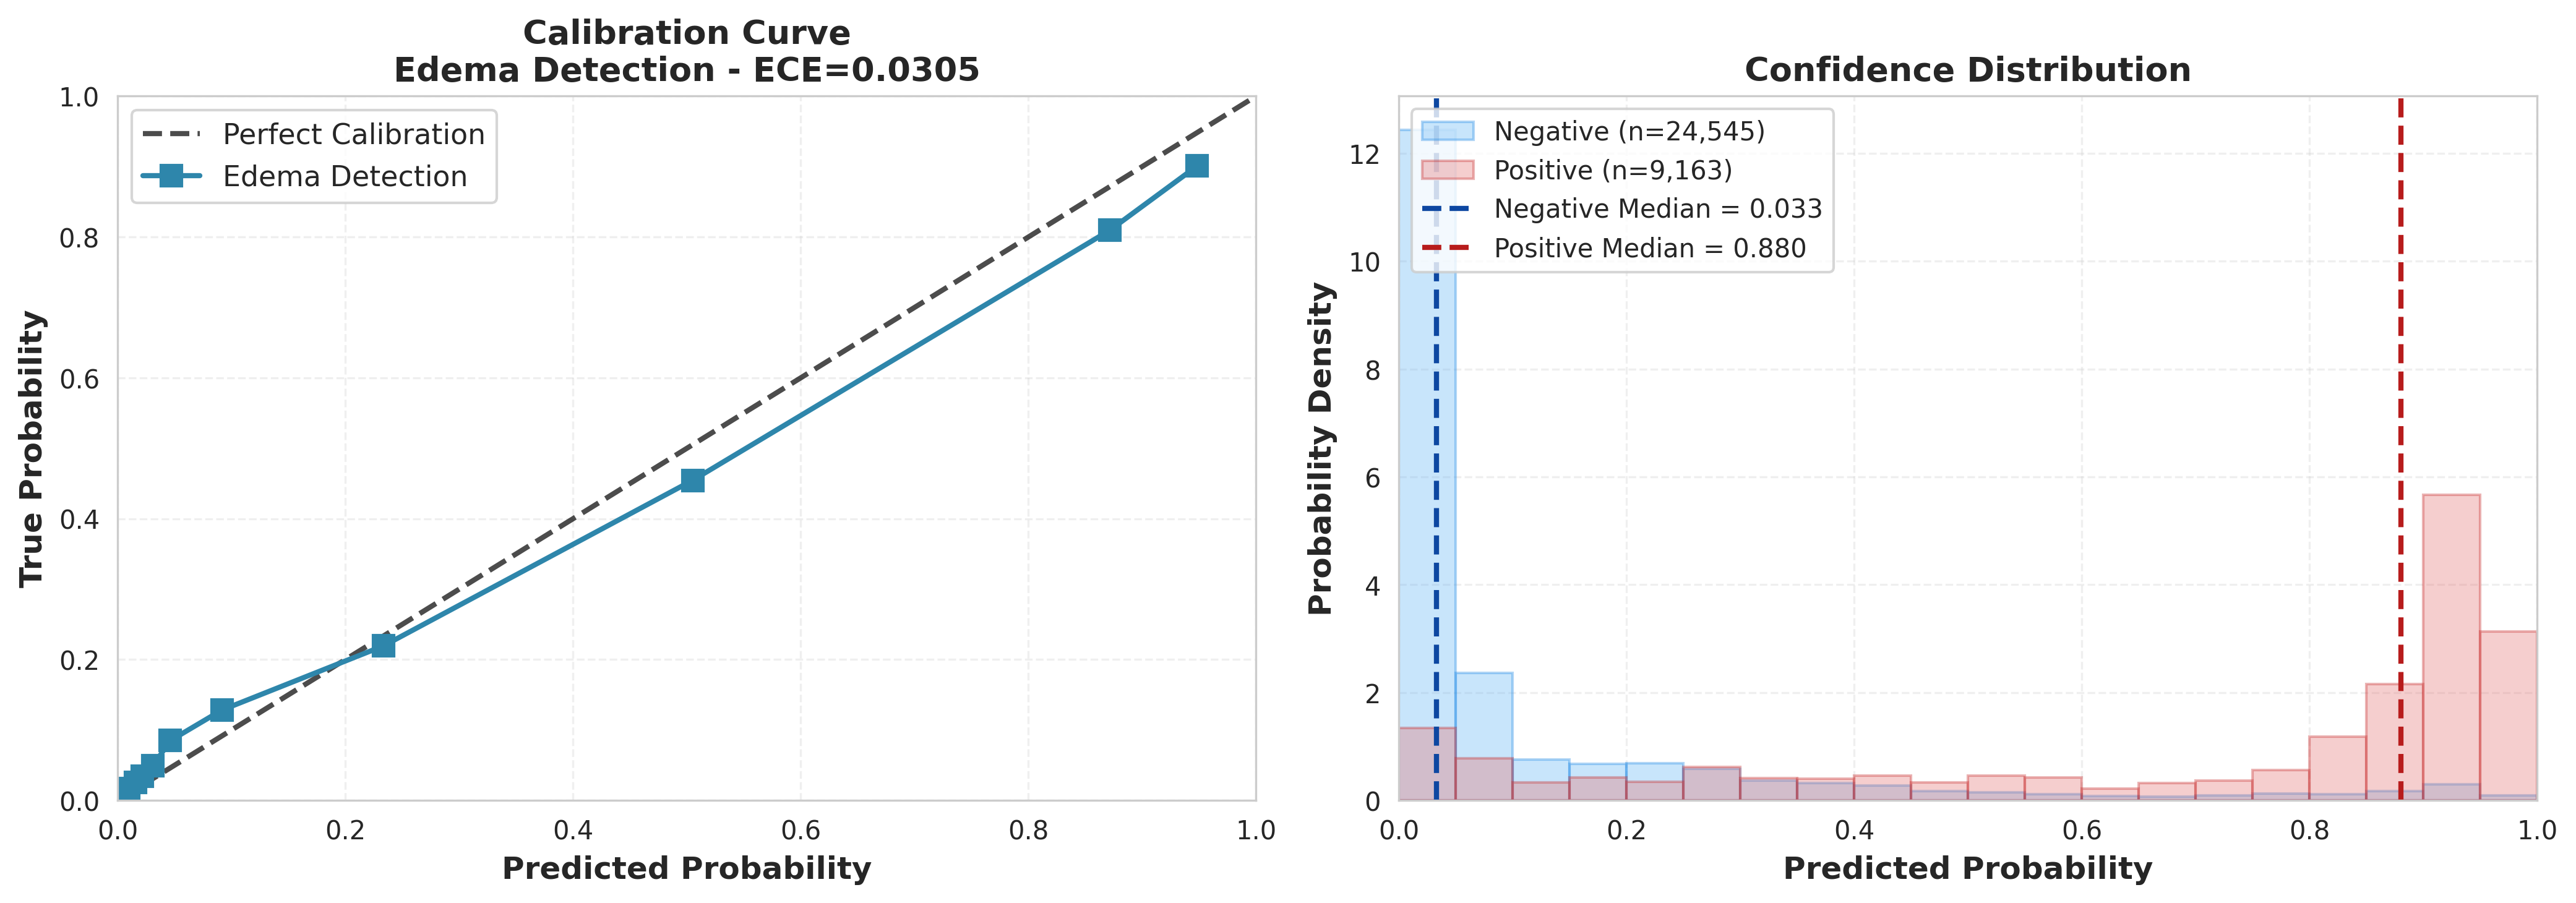

In [ ]:
edema_valid = predictions_df[predictions_df['edema_true'].isin([0, 1])].copy()

y_true_edema = edema_valid['edema_true'].values
y_prob_edema = edema_valid['edema_prob'].values

ece_calc = ExpectedCalibrationError(n_bins=10)
ece_edema, bin_stats_edema = ece_calc.compute(y_true_edema, y_prob_edema)

print(f"Edema Detection:")
print(f"  ECE: {ece_edema:.4f}")
print(f"  AUROC: {roc_auc_score(y_true_edema, y_prob_edema):.4f}")
print(f"  AUPRC: {average_precision_score(y_true_edema, y_prob_edema):.4f}")

plot_calibration_curve(
    y_true_edema, y_prob_edema,
    task_name='Edema Detection',
    n_bins=10,
    save_path=f"{OUTPUT_DIR}/edema_detection_calibration.png"
)

display(Image(f"{OUTPUT_DIR}/edema_detection_calibration.png"))

### 1.2 Subtype Classification Calibration (CPE vs NCPE)


Subtype Classification (CPE vs NCPE):
  ECE: 0.1003
  AUROC: 0.9577
  AUPRC: 0.9387
📊 Calibration plot saved: ./output/calibration_analysis/experiment_9/subtype_calibration.png


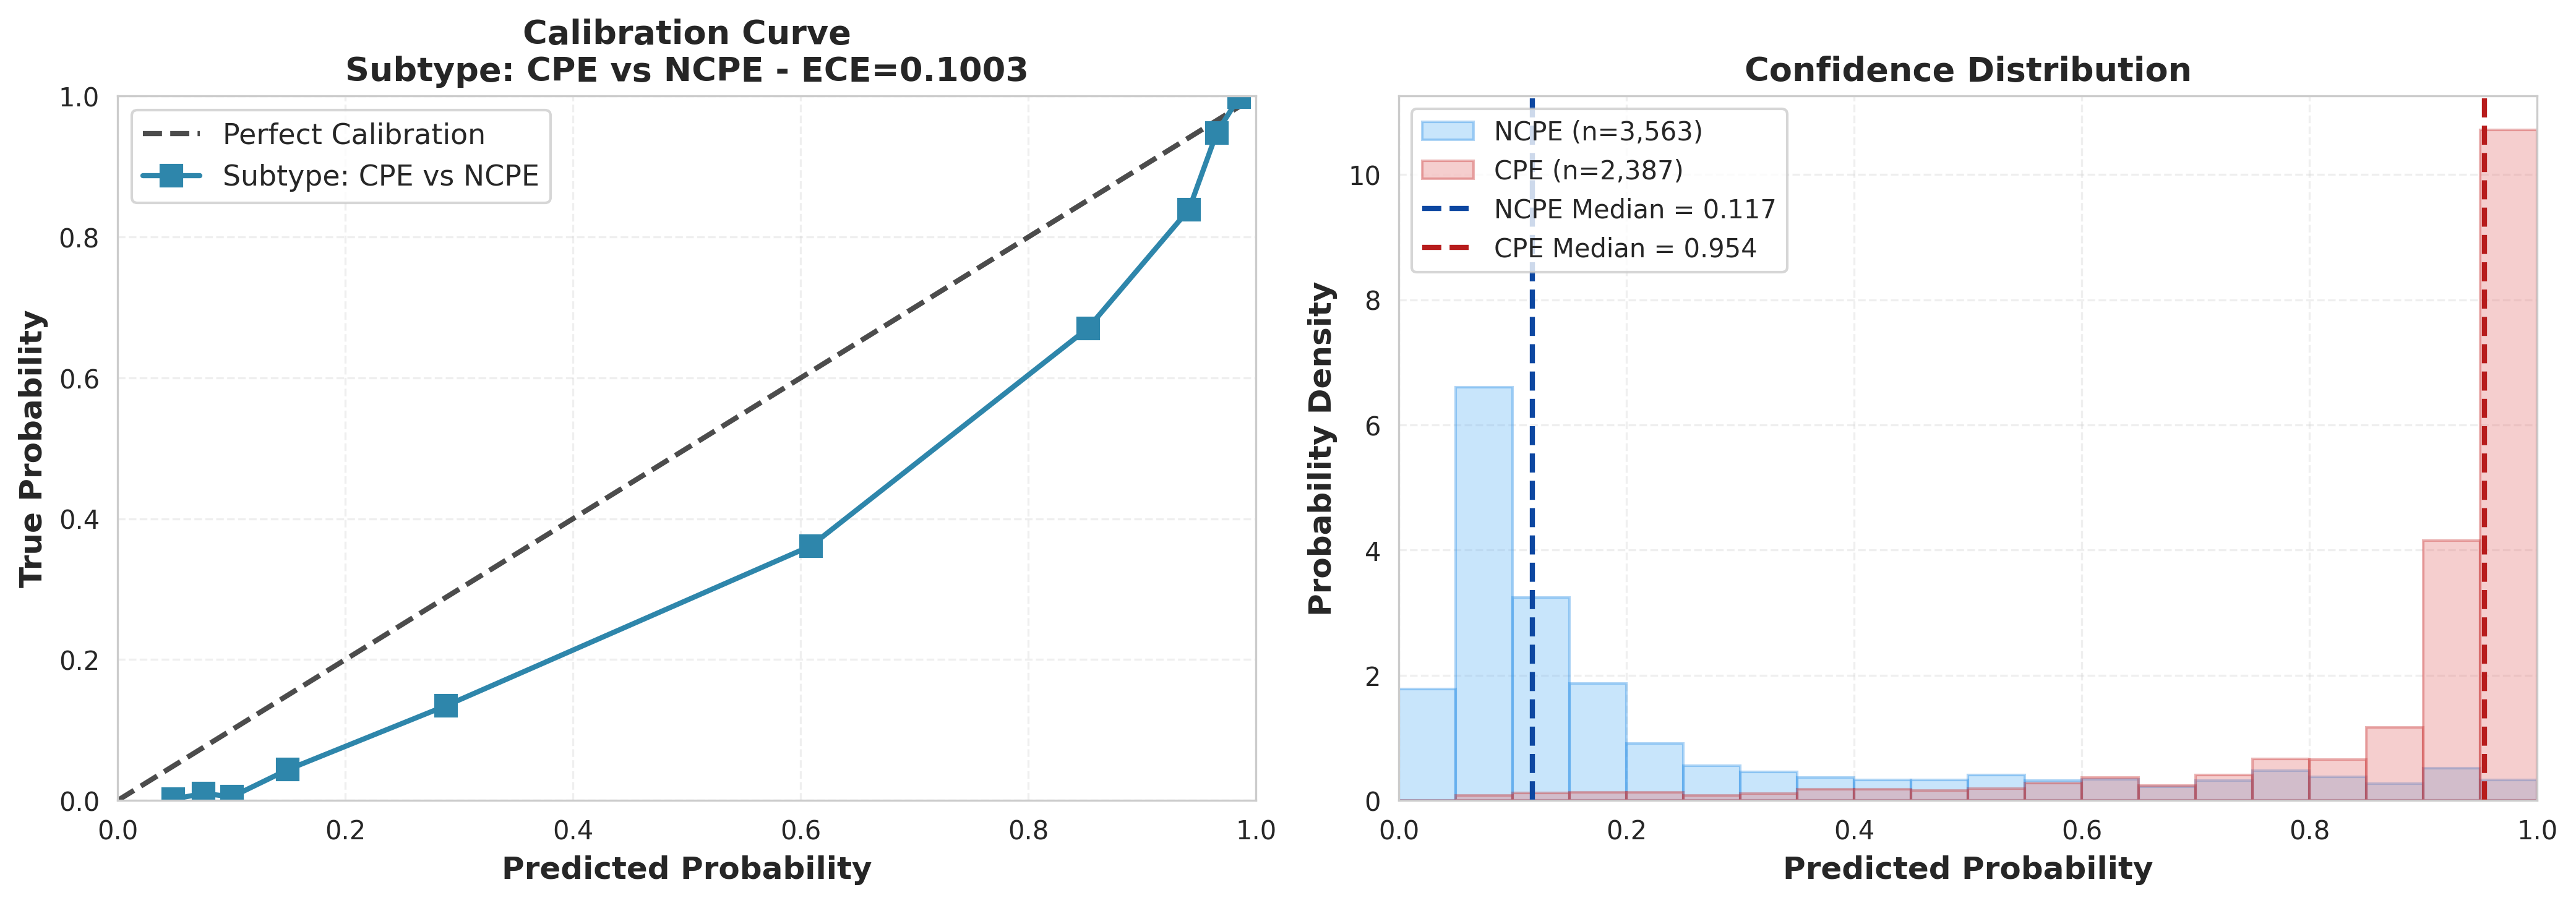

In [ ]:
subtype_valid = predictions_df[
    (predictions_df['edema_true'] == 1) & 
    (predictions_df['subtype_true'].isin([0, 1]))
].copy()

y_true_subtype = subtype_valid['subtype_true'].values
y_prob_subtype_cpe = subtype_valid['subtype_prob_cpe'].values

ece_subtype, bin_stats_subtype = ece_calc.compute(y_true_subtype, y_prob_subtype_cpe)

print(f"\nSubtype Classification (CPE vs NCPE):")
print(f"  ECE: {ece_subtype:.4f}")
print(f"  AUROC: {roc_auc_score(y_true_subtype, y_prob_subtype_cpe):.4f}")
print(f"  AUPRC: {average_precision_score(y_true_subtype, y_prob_subtype_cpe):.4f}")

plot_calibration_curve(
    y_true_subtype, y_prob_subtype_cpe,
    task_name='Subtype: CPE vs NCPE',
    class_names=('NCPE', 'CPE'),
    n_bins=10,
    save_path=f"{OUTPUT_DIR}/subtype_calibration.png"
)

display(Image(f"{OUTPUT_DIR}/subtype_calibration.png"))

### 1.3 3-Class Calibration (Negative, NCPE, CPE)

In [ ]:
class3_valid = predictions_df[
    (predictions_df['edema_true'] == 0) | 
    ((predictions_df['edema_true'] == 1) & predictions_df['subtype_true'].isin([0, 1]))
].copy()

class3_valid['prob_negative'] = 1 - class3_valid['edema_prob']
class3_valid['prob_ncpe'] = class3_valid['edema_prob'] * class3_valid['subtype_prob_ncpe']
class3_valid['prob_cpe'] = class3_valid['edema_prob'] * class3_valid['subtype_prob_cpe']

class3_labels = np.zeros(len(class3_valid), dtype=int)
class3_labels[(class3_valid['edema_true'] == 1) & (class3_valid['subtype_true'] == 0)] = 1  # NCPE
class3_labels[(class3_valid['edema_true'] == 1) & (class3_valid['subtype_true'] == 1)] = 2  # CPE

class_names = ['Negative', 'NCPE', 'CPE']
prob_cols = ['prob_negative', 'prob_ncpe', 'prob_cpe']

for class_idx, (class_name, prob_col) in enumerate(zip(class_names, prob_cols)):
    y_binary = (class3_labels == class_idx).astype(int)
    y_prob_binary = class3_valid[prob_col].values
    
    if len(np.unique(y_binary)) == 2:
        ece_class, _ = ece_calc.compute(y_binary, y_prob_binary)
        
        print(f"\n3-Class OVR: {class_name}")
        print(f"  ECE: {ece_class:.4f}")
        
        plot_calibration_curve(
            y_binary, y_prob_binary,
            task_name=f'3-class OVR: {class_name}',
            class_names = {f'Not {class_name}', class_name},
            n_bins=10,
            save_path=f"{OUTPUT_DIR}/3class_{class_name.lower()}_calibration.png"
        )


3-Class OVR: Negative
  ECE: 0.0405
📊 Calibration plot saved: ./output/calibration_analysis/experiment_9/3class_negative_calibration.png

3-Class OVR: NCPE
  ECE: 0.0181
📊 Calibration plot saved: ./output/calibration_analysis/experiment_9/3class_ncpe_calibration.png

3-Class OVR: CPE
  ECE: 0.0302
📊 Calibration plot saved: ./output/calibration_analysis/experiment_9/3class_cpe_calibration.png


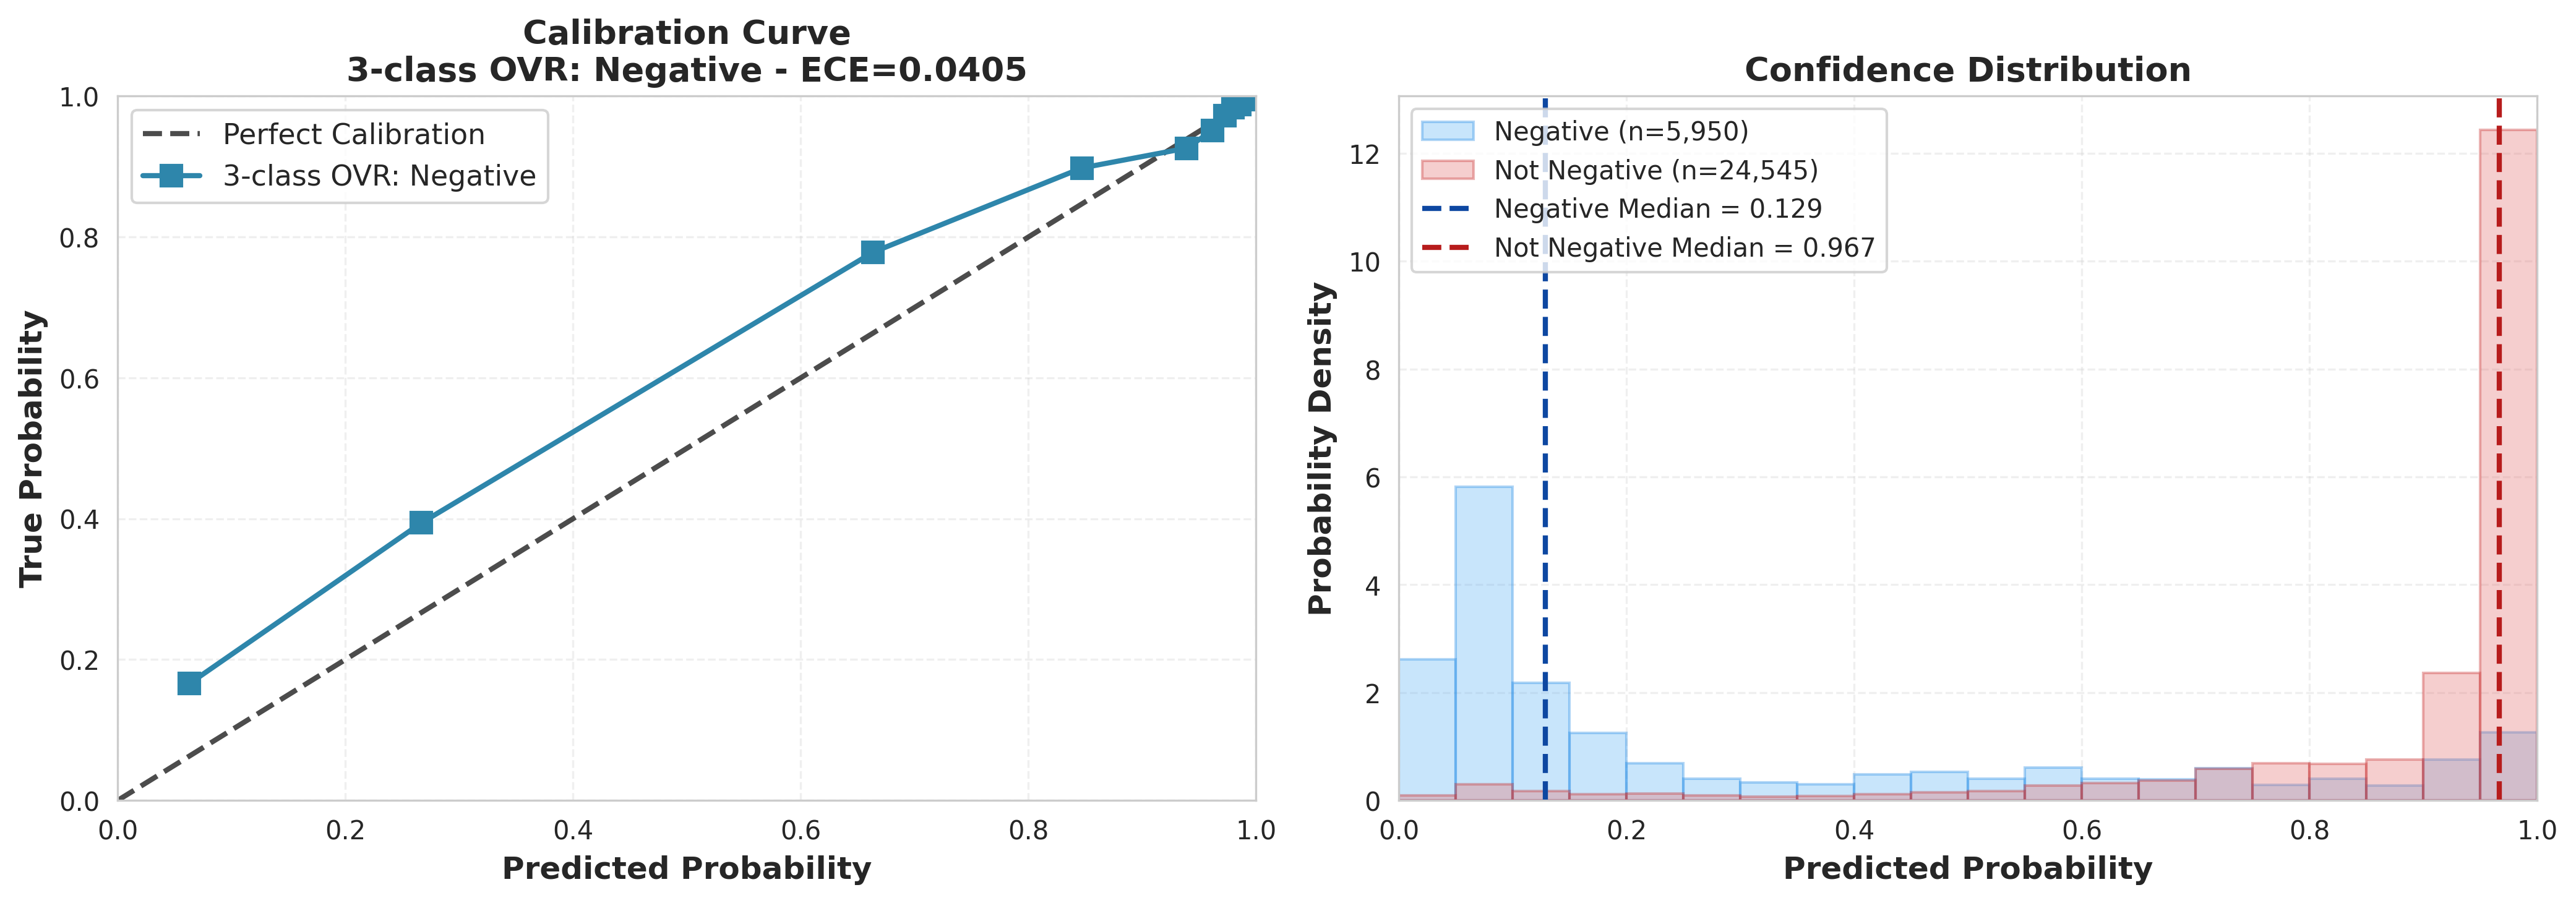

In [ ]:
display(Image(f"{OUTPUT_DIR}/3class_negative_calibration.png"))

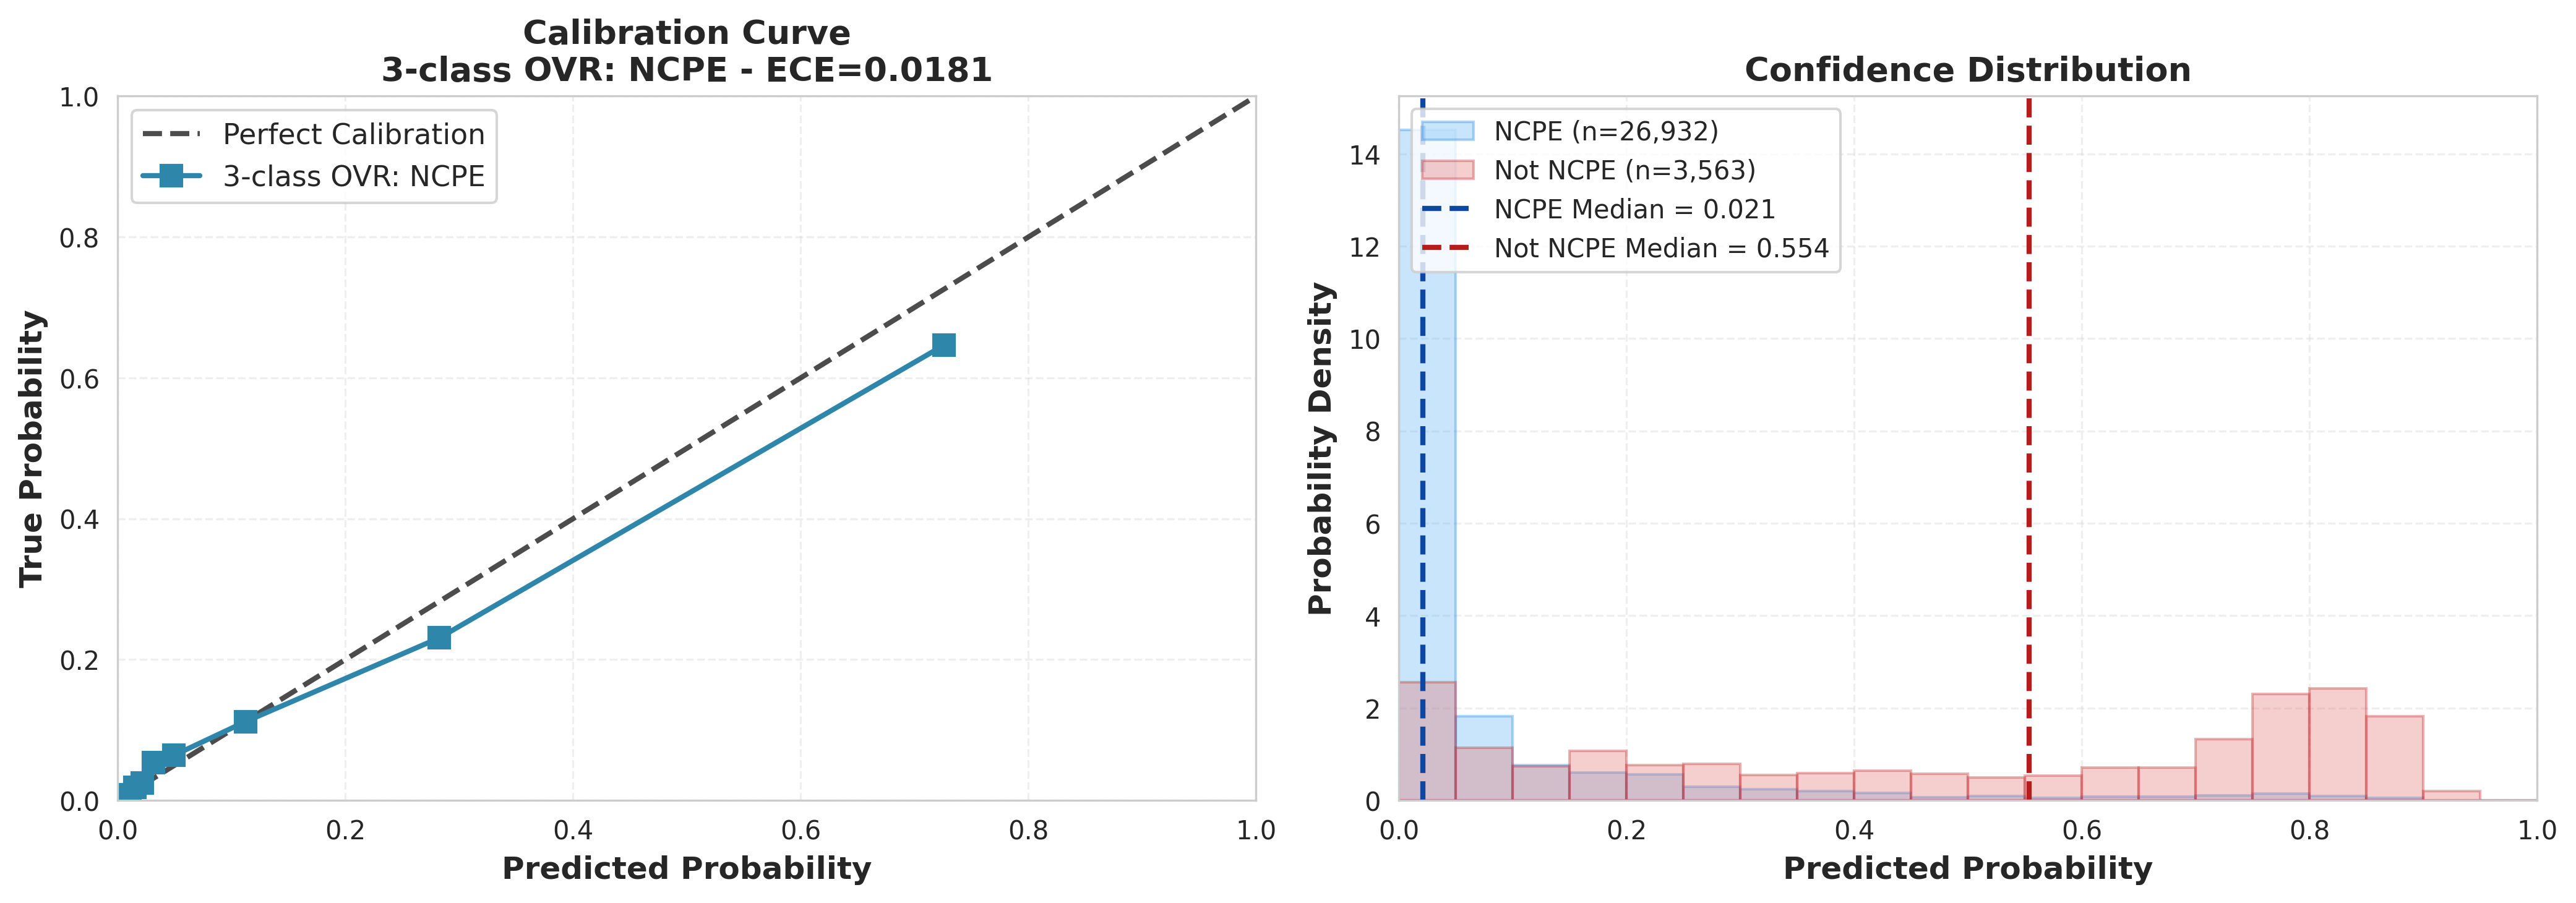

In [ ]:
display(Image(f"{OUTPUT_DIR}/3class_ncpe_calibration.png"))

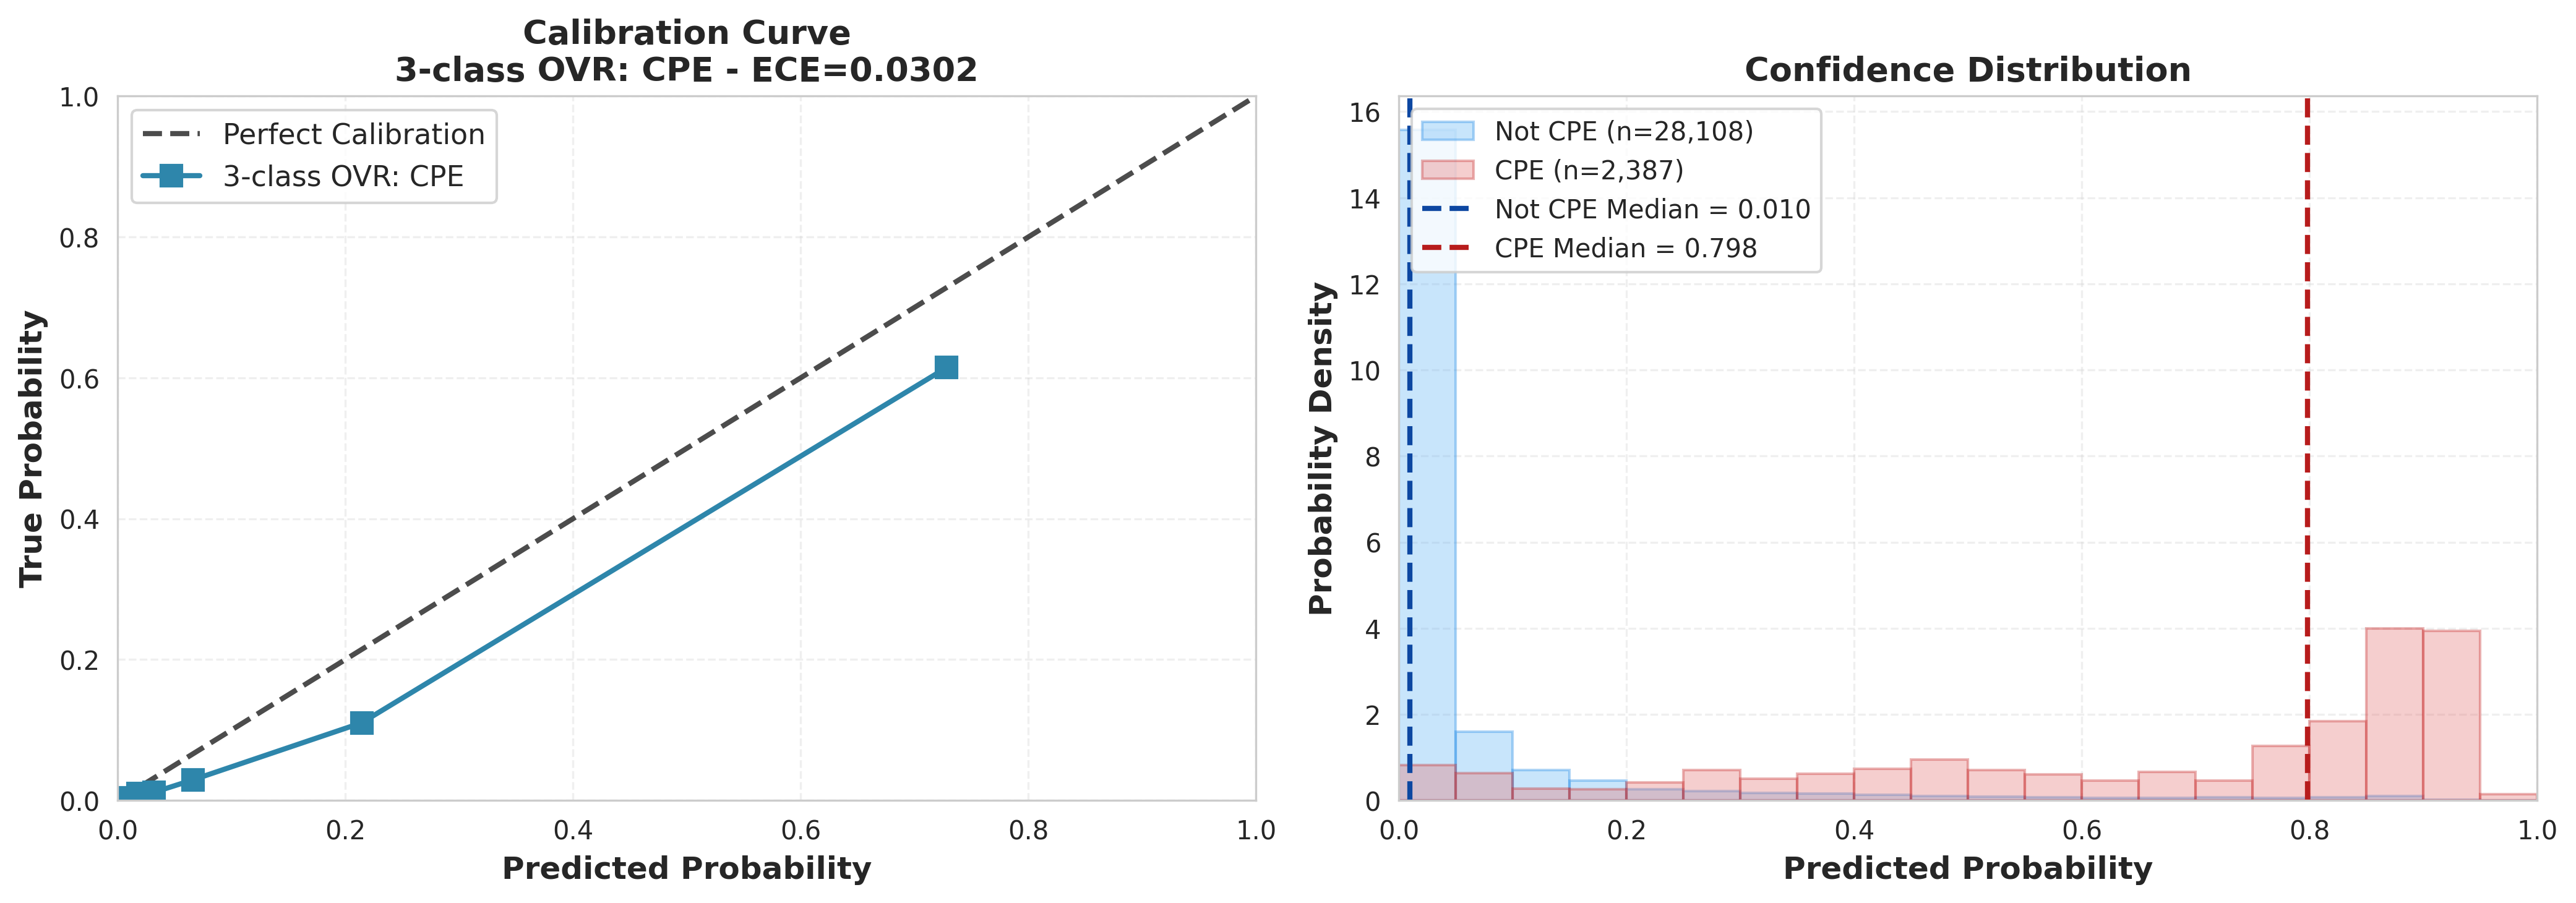

In [ ]:
display(Image(f"{OUTPUT_DIR}/3class_cpe_calibration.png"))

# 2. Decison Curve Analysis

In [12]:
edema_valid = predictions_df[predictions_df['edema_true'].isin([0, 1])].copy()
y_true_edema = edema_valid['edema_true'].values
y_prob_edema = edema_valid['edema_prob'].values

print(f"Positive (edema=1): {(y_true_edema == 1).sum()} ({100*(y_true_edema==1).mean():.2f}%)")
print(f"Negative (edema=0): {(y_true_edema == 0).sum()} ({100*(y_true_edema==0).mean():.2f}%)")

prevalence = (y_true_edema == 1).mean()
print(f"\nPrevalence: {prevalence:.4f}")

Positive (edema=1): 9163 (27.18%)
Negative (edema=0): 24545 (72.82%)

Prevalence: 0.2718


In [13]:
print(f"[2] Probability Distribution")
print(f"Min: {y_prob_edema.min():.6f}")
print(f"Max: {y_prob_edema.max():.6f}")
print(f"Mean: {y_prob_edema.mean():.6f}")
print(f"Median: {np.median(y_prob_edema):.6f}")
print(f"Std: {y_prob_edema.std():.6f}")

print(f"\n[3] Quartiles")
print(f"25th percentile: {np.percentile(y_prob_edema, 25):.6f}")
print(f"50th percentile: {np.percentile(y_prob_edema, 50):.6f}")
print(f"75th percentile: {np.percentile(y_prob_edema, 75):.6f}")
print(f"95th percentile: {np.percentile(y_prob_edema, 95):.6f}")
print(f"99th percentile: {np.percentile(y_prob_edema, 99):.6f}")

[2] Probability Distribution
Min: 0.004468
Max: 0.983597
Mean: 0.272715
Median: 0.055005
Std: 0.349469

[3] Quartiles
25th percentile: 0.020332
50th percentile: 0.055005
75th percentile: 0.469399
95th percentile: 0.945801
99th percentile: 0.964321


In [14]:
print(f"AUROC: {roc_auc_score(y_true_edema, y_prob_edema):.4f}")
print(f"AUPRC: {average_precision_score(y_true_edema, y_prob_edema):.4f}")

AUROC: 0.9102
AUPRC: 0.8138


In [15]:
"""
Sensitivity: 실제 폐부종 환자 중 실제 양성인 경우의 비율
Specificity: 건강한 환자 중 실제 음성인 경우의 비율
PPV: 알림 N개 중 실제 양성인 경우의 비율
Alert rate: 전체 환자의 N%에게 알림 발생
"""

for threshold in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]:
    preds = (y_prob_edema >= threshold).astype(int)
    tp = ((preds == 1) & (y_true_edema == 1)).sum()
    fp = ((preds == 1) & (y_true_edema == 0)).sum()
    tn = ((preds == 0) & (y_true_edema == 0)).sum()
    fn = ((preds == 0) & (y_true_edema == 1)).sum()
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    
    print(f"Threshold {threshold}:")
    print(f"  TP={tp:5d}  FP={fp:5d}  TN={tn:5d}  FN={fn:5d}")
    print(f"  Sensitivity: {sensitivity:.4f}")
    print(f"  Specificity: {specificity:.4f}")  
    print(f"  PPV: {ppv:.4f}")
    print(f"  Alert rate: {tp + fp} ({100*(tp+fp)/len(y_true_edema):.1f}%)\n")

Threshold 0.1:
  TP= 8174  FP= 6297  TN=18248  FN=  989
  Sensitivity: 0.8921
  Specificity: 0.7435
  PPV: 0.5649
  Alert rate: 14471 (42.9%)

Threshold 0.2:
  TP= 7804  FP= 4448  TN=20097  FN= 1359
  Sensitivity: 0.8517
  Specificity: 0.8188
  PPV: 0.6370
  Alert rate: 12252 (36.3%)

Threshold 0.3:
  TP= 7349  FP= 2922  TN=21623  FN= 1814
  Sensitivity: 0.8020
  Specificity: 0.8810
  PPV: 0.7155
  Alert rate: 10271 (30.5%)

Threshold 0.4:
  TP= 6957  FP= 2119  TN=22426  FN= 2206
  Sensitivity: 0.7592
  Specificity: 0.9137
  PPV: 0.7665
  Alert rate: 9076 (26.9%)

Threshold 0.5:
  TP= 6595  FP= 1596  TN=22949  FN= 2568
  Sensitivity: 0.7197
  Specificity: 0.9350
  PPV: 0.8052
  Alert rate: 8191 (24.3%)

Threshold 0.6:
  TP= 6214  FP= 1278  TN=23267  FN= 2949
  Sensitivity: 0.6782
  Specificity: 0.9479
  PPV: 0.8294
  Alert rate: 7492 (22.2%)



In [23]:
threshold = float(input("threshold:"))
print(f"\n[6] Manual Net Benefit Calculation (threshold={threshold})")

preds = (y_prob_edema >= threshold).astype(int)
tp = ((preds == 1) & (y_true_edema == 1)).sum()
fp = ((preds == 1) & (y_true_edema == 0)).sum()
n = len(y_true_edema)

nb_model = (tp / n) - (fp / n) * (threshold / (1 - threshold))
print(f"TP/N = {tp}/{n} = {tp/n:.4f}")
print(f"FP/N = {fp}/{n} = {fp/n:.4f}")
print(f"pt/(1-pt) = {threshold}/{1-threshold} = {threshold/(1-threshold):.4f}")
print(f"Model Net Benefit = {tp/n:.4f} - {fp/n:.4f} × {threshold/(1-threshold):.4f} = {nb_model:.4f}")

# Treat All
tp_all = (y_true_edema == 1).sum()
fp_all = (y_true_edema == 0).sum()
nb_all = (tp_all / n) - (fp_all / n) * (threshold / (1 - threshold))
print(f"\nTreat All Net Benefit = {nb_all:.4f}")


[6] Manual Net Benefit Calculation (threshold=0.5)
TP/N = 6595/33708 = 0.1957
FP/N = 1596/33708 = 0.0473
pt/(1-pt) = 0.5/0.5 = 1.0000
Model Net Benefit = 0.1957 - 0.0473 × 1.0000 = 0.1483

Treat All Net Benefit = -0.4563


In [17]:
dca_edema = compute_dca(
    y_true=y_true_edema,
    y_prob=y_prob_edema,
    thresholds=np.linspace(0.01, 0.99, 99)
)

dca_edema.head()

,threshold,nb_model,tp,fp,n_alerts,nb_all,nb_none
0,0.01,0.263946,9125,22563,31688,0.264479,0.0
1,0.02,0.255502,8952,16638,25590,0.256974,0.0
2,0.03,0.249397,8799,12685,21484,0.249314,0.0
3,0.04,0.244011,8656,10341,18997,0.241494,0.0
4,0.05,0.238385,8509,8997,17506,0.233510,0.0


In [24]:
from importlib import reload
import training.decision_curve_analysis
reload(training.decision_curve_analysis)

from training.decision_curve_analysis import plot_dca_curve, analyze_optimal_threshold

📈 DCA plot saved: ./output/calibration_analysis/experiment_9/dca_edema_detection.png


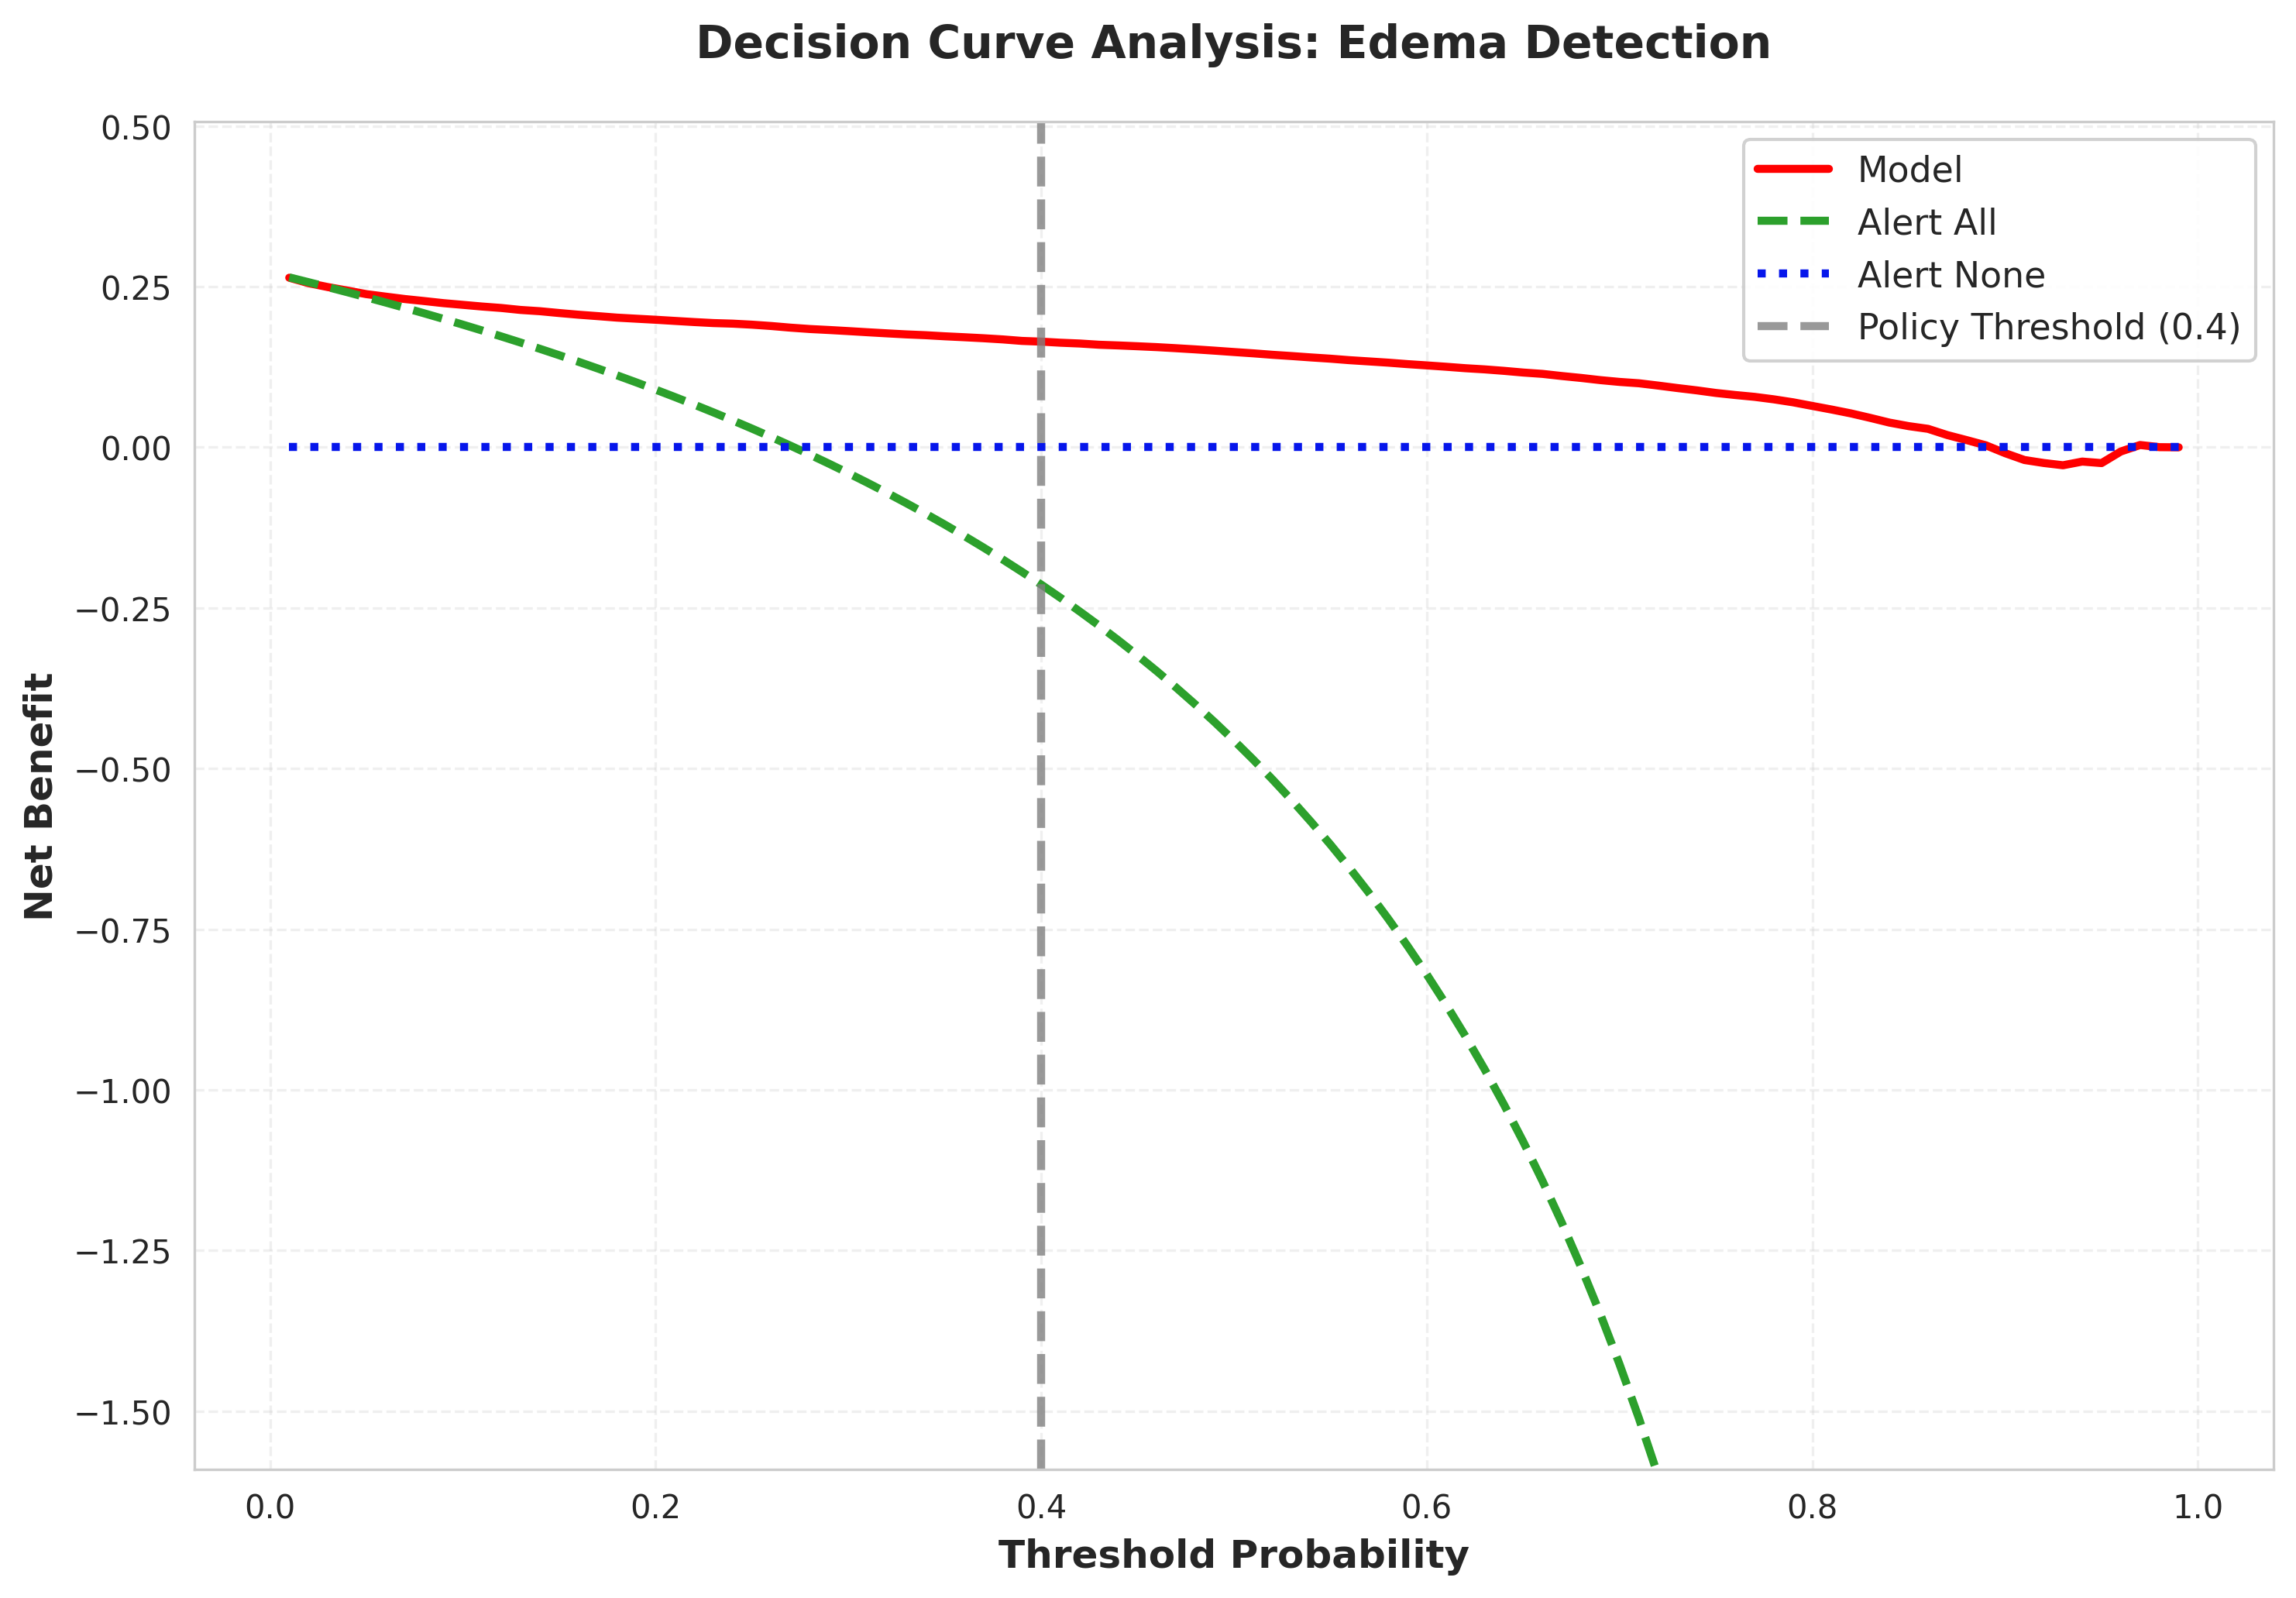

In [25]:
fig = plot_dca_curve(
    dca_df=dca_edema,
    title="Decision Curve Analysis: Edema Detection",
    save_path=f"{OUTPUT_DIR}/dca_edema_detection.png",
    figsize=(10, 7),
    show_alerts=False,
    policy_threshold=0.4
)

display(Image(f"{OUTPUT_DIR}/dca_edema_detection.png"))

In [20]:
optimal_edema = analyze_optimal_threshold(dca_edema, verbose=True)


📊 Optimal Threshold Analysis
Optimal threshold: 0.010
Maximum net benefit: 0.2639
True positives: 9125.0
False positives: 22563.0
Number of alerts: 31688.0

Clinically useful range: [0.030, 0.980]

